In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.31079475671223233,train_accu=0.8965142857142857
Epoch=0,valid_loss=0.38760804951190947,valid_accu=0.8638
0
Epoch=1,train_loss=0.25326097658872604,train_accu=0.9118285714285714
Epoch=1,valid_loss=0.3703739182949066,valid_accu=0.8736
0
Epoch=2,train_loss=0.1521947123744658,train_accu=0.9494857142857143
Epoch=2,valid_loss=0.3038599440455437,valid_accu=0.8997
0
Epoch=3,train_loss=0.11787318630814553,train_accu=0.9622
Epoch=3,valid_loss=0.3031278470277786,valid_accu=0.9007
0
Epoch=4,train_loss=0.08532358796149492,train_accu=0.9734571428571429
Epoch=4,valid_loss=0.2890126455038786,valid_accu=0.9029
0
Epoch=5,train_loss=0.09726371616934026,train_accu=0.9691428571428572
Epoch=5,valid_loss=0.3121401816010475,valid_accu=0.8978
Epoch=6,train_loss=0.07925855019092559,train_accu=0.9748
Epoch=6,valid_loss=0.2953142110228539,valid_accu=0.9019
Epoch=7,train_loss=0.07046529761574098,train_accu=0.9783142857142857
Epoch=7,valid_loss=0.33133177329301833,valid_accu=0.8994
Epoch=8,train

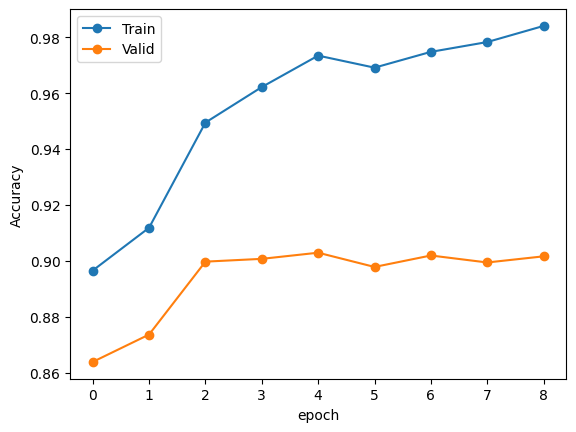

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_10.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.0855196880495974, 0.9736857142857143)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.28762984793186186, 0.9062)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

airplane      0.966456
automobile    0.976403
bird          0.953428
cat           0.928879
deer          0.982896
dog           0.962815
frog          0.991203
horse         0.990865
ship          0.992693
truck         0.990297
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(5).index.map(trainset.dataset.classess)]
targetF

[3, 2, 5, 0, 1]

In [17]:
targetF=[0,1,8,9]

In [18]:
 #將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                     

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t==0):
                            indexT.append(idx.cpu().numpy().item()) 
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                    

            torch.cuda.empty_cache() 
        return indexF,indexT

In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(14025, 24463)

In [20]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4006, 6987)

In [21]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                if(t!=0):
                    flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                    flat_data.append(d.cpu().numpy()) 
                
    return flat_data,flat_true

In [22]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [24]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.0016157777961724352,train_accu=0.9995874587458746
Epoch=0,valid_loss=0.023490683872920394,valid_accu=0.9934495392472521
0
Epoch=1,train_loss=0.0009728798901708177,train_accu=0.9997778624016248
Epoch=1,valid_loss=0.02927745865171391,valid_accu=0.9931164649716887
Epoch=2,train_loss=0.0006111616089781352,train_accu=0.9997461284589998
Epoch=2,valid_loss=0.03510161516964643,valid_accu=0.9925613411790829
Epoch=3,train_loss=0.00012534743029124842,train_accu=0.99993653211475
Epoch=3,valid_loss=0.03798279779346025,valid_accu=0.9924503164205618
Epoch=4,train_loss=0.0002579147675248698,train_accu=0.9999047981721249
Epoch=4,valid_loss=0.03888338316054368,valid_accu=0.9924503164205618
4 Early stopping!


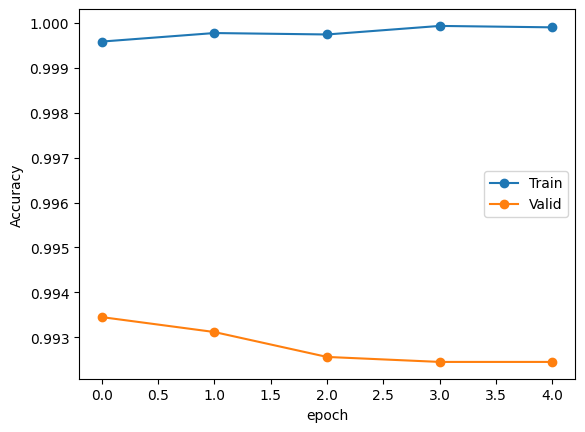

In [25]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [26]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.09140659711317854,train_accu=0.9701998937170421
Epoch=0,valid_loss=0.33458410602891225,valid_accu=0.8929440389294404
0
Epoch=1,train_loss=0.08002027653457175,train_accu=0.9743694559130115
Epoch=1,valid_loss=0.36326179935242187,valid_accu=0.8870759982825247
Epoch=2,train_loss=0.06456592579156785,train_accu=0.9815639946040959
Epoch=2,valid_loss=0.31657481424726946,valid_accu=0.9006726778302562
0
Epoch=3,train_loss=0.058038657801453446,train_accu=0.98279033642644
Epoch=3,valid_loss=0.3668311356653621,valid_accu=0.8886503506512093
Epoch=4,train_loss=0.06260974597464071,train_accu=0.9799697502350488
Epoch=4,valid_loss=0.36867983540549665,valid_accu=0.8872191212251324
Epoch=5,train_loss=0.04127685948303316,train_accu=0.9876139475943261
Epoch=5,valid_loss=0.3425257255910923,valid_accu=0.8956633748389867
Epoch=6,train_loss=0.02734849189261894,train_accu=0.9921514123369988
Epoch=6,valid_loss=0.35744113139610906,valid_accu=0.9015314154859024
0
Epoch=7,train_loss=0.0370145126

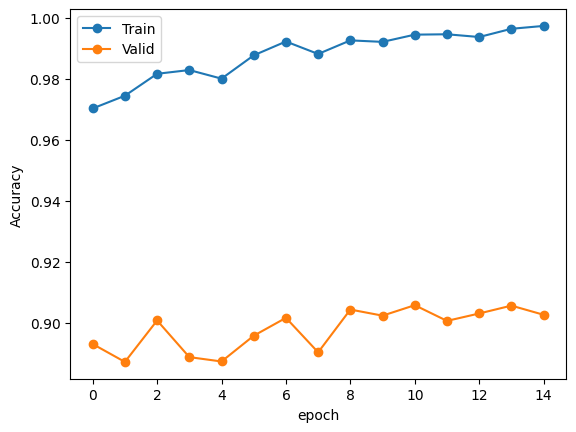

In [27]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [28]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.04421114716911274,train_accu=0.9860249554367202
Epoch=0,valid_loss=0.17440936971070822,valid_accu=0.9435846230654019
0
Epoch=1,train_loss=0.02130176119383511,train_accu=0.9928698752228164
Epoch=1,valid_loss=0.174879646243521,valid_accu=0.9513230154767848
0
Epoch=2,train_loss=0.03476325740810291,train_accu=0.9881639928698752
Epoch=2,valid_loss=0.21760360645878868,valid_accu=0.9425861208187718
Epoch=3,train_loss=0.013172325234334757,train_accu=0.9957219251336898
Epoch=3,valid_loss=0.17578164254758308,valid_accu=0.9520718921617574
0
Epoch=4,train_loss=0.02944236765643864,train_accu=0.9898039215686274
Epoch=4,valid_loss=0.17990403122878185,valid_accu=0.9453320019970045
Epoch=5,train_loss=0.009268722952258546,train_accu=0.9970053475935828
Epoch=5,valid_loss=0.16662635893597677,valid_accu=0.9513230154767848
Epoch=6,train_loss=0.009282129551711494,train_accu=0.997361853832442
Epoch=6,valid_loss=0.1579045512170879,valid_accu=0.9560659011482776
0
Epoch=7,train_loss=0.011087

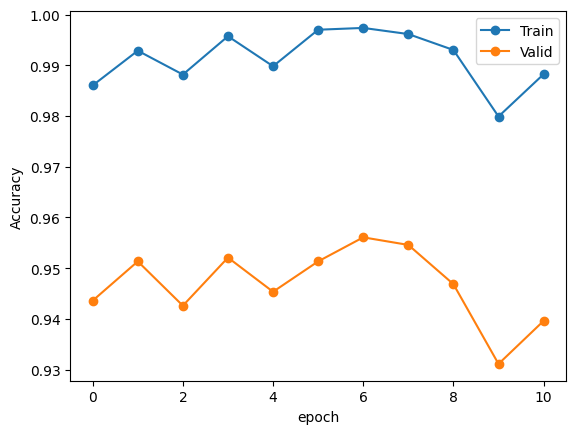

In [29]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [30]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0016157777961724352, 0.9995874587458746)

In [31]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.023490683872920394, 0.9934495392472521)

In [32]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.021054995683187566, 0.994931120467645)

In [33]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.00906259759740967, 0.9975044563279858)

In [34]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.3634448753323561, 0.9006726778302562)

In [35]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.15439135505558846, 0.9558162755866201)

In [36]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.01584991898403636, 0.9960857142857142, 14025)

In [37]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.29811592157781125, 0.9186, 4006)

In [38]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.033237129782432956, 0.9945714285714286, 11818, 23182)

In [39]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.3816459550231695, 0.9124, 3364, 6636)

In [40]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [41]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.085520,0.973686,0.287630,0.906200
1,Model_Decision,0.001616,0.999587,0.023491,0.993450
2,Model_T,0.021055,0.994931,0.363445,0.900673
3,Model_F,0.009063,0.997504,0.154391,0.955816
4,Total_Model,0.033237,0.994571,0.381646,0.912400
5,Total_Model_without_decision,0.015850,0.996086,0.298116,0.918600


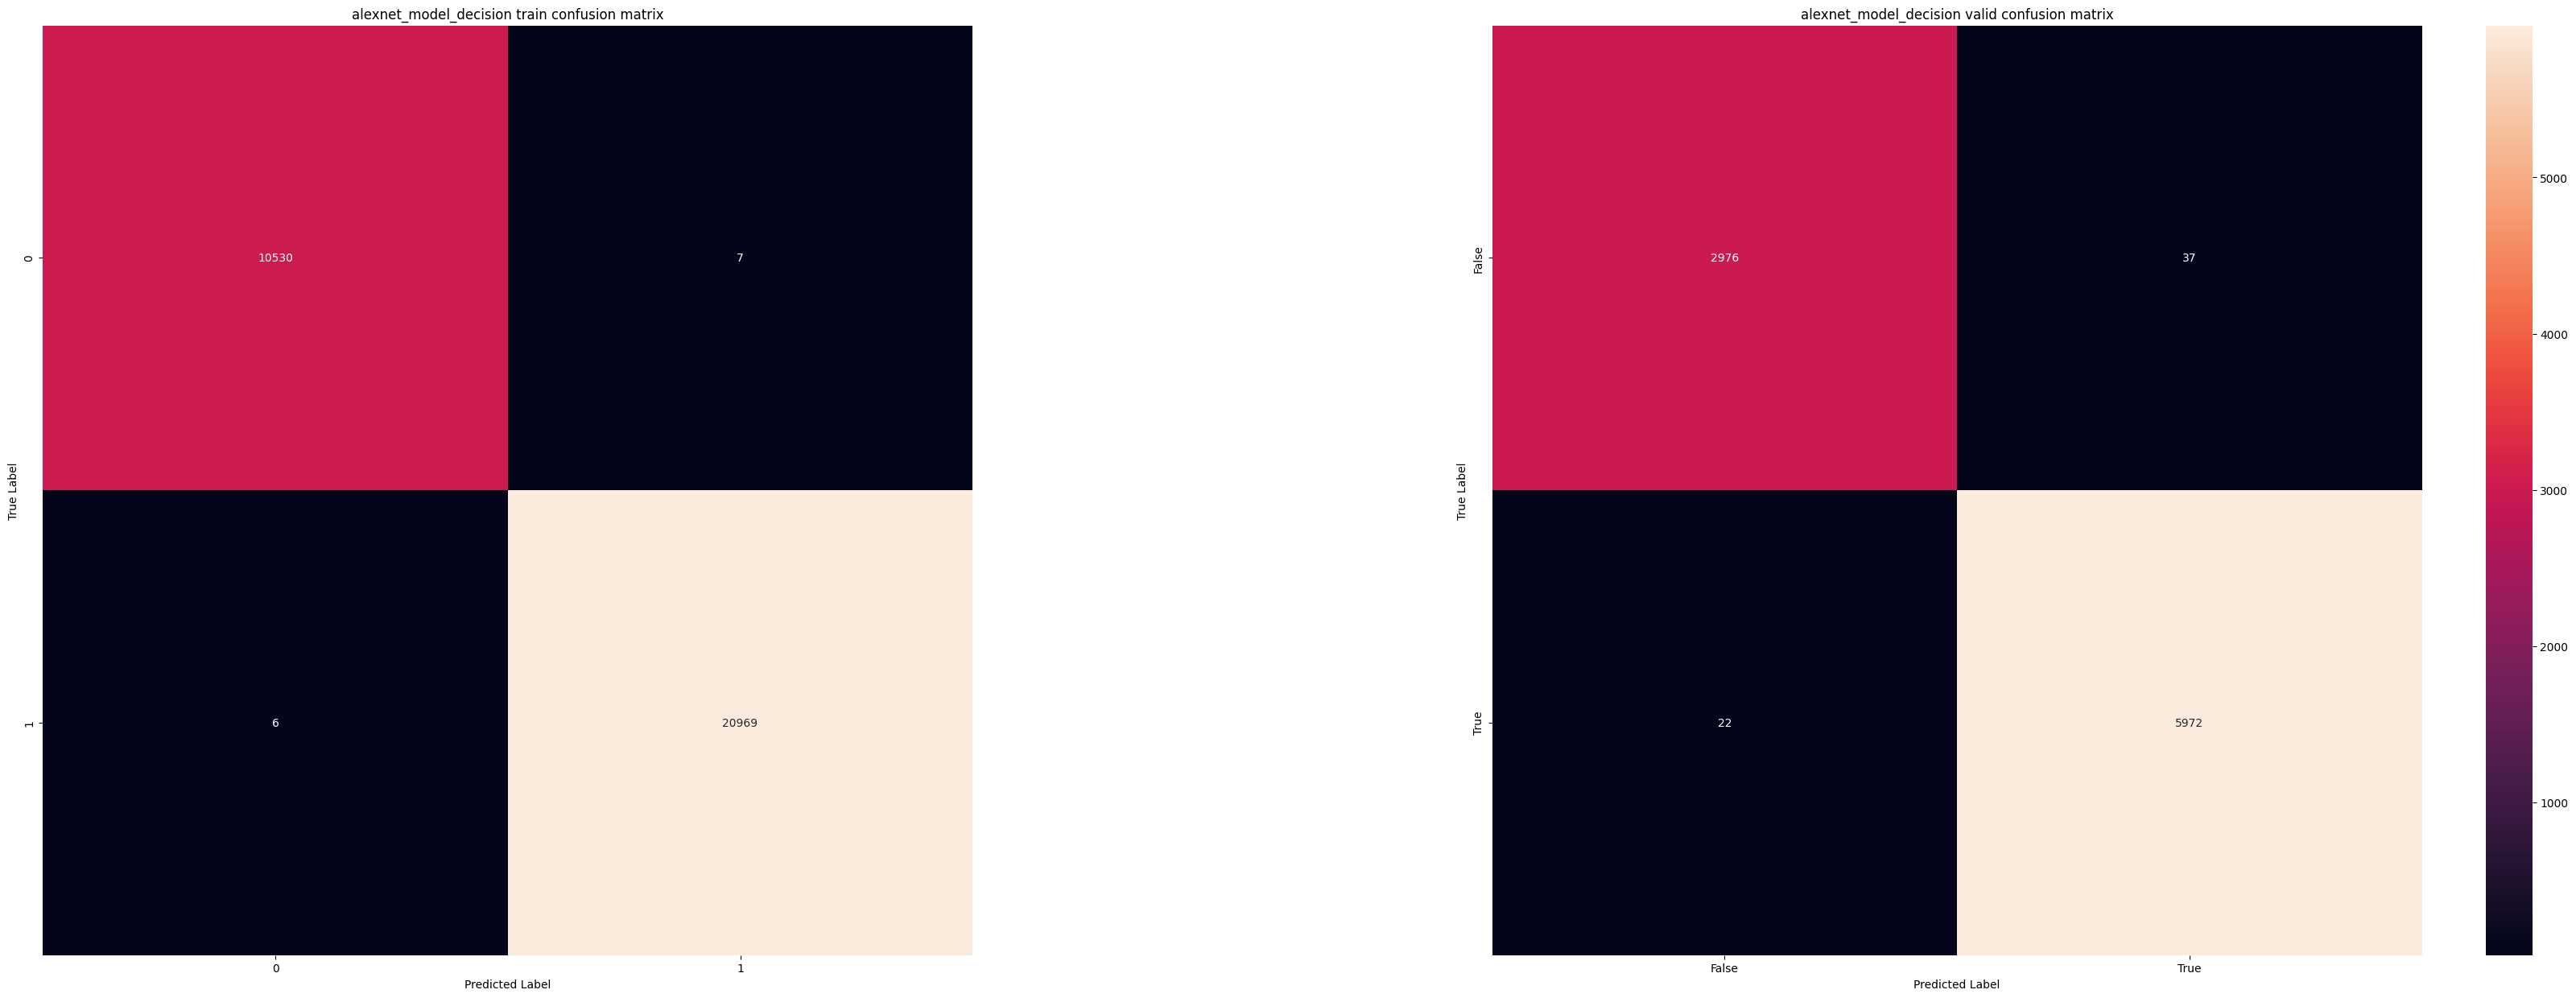

In [42]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

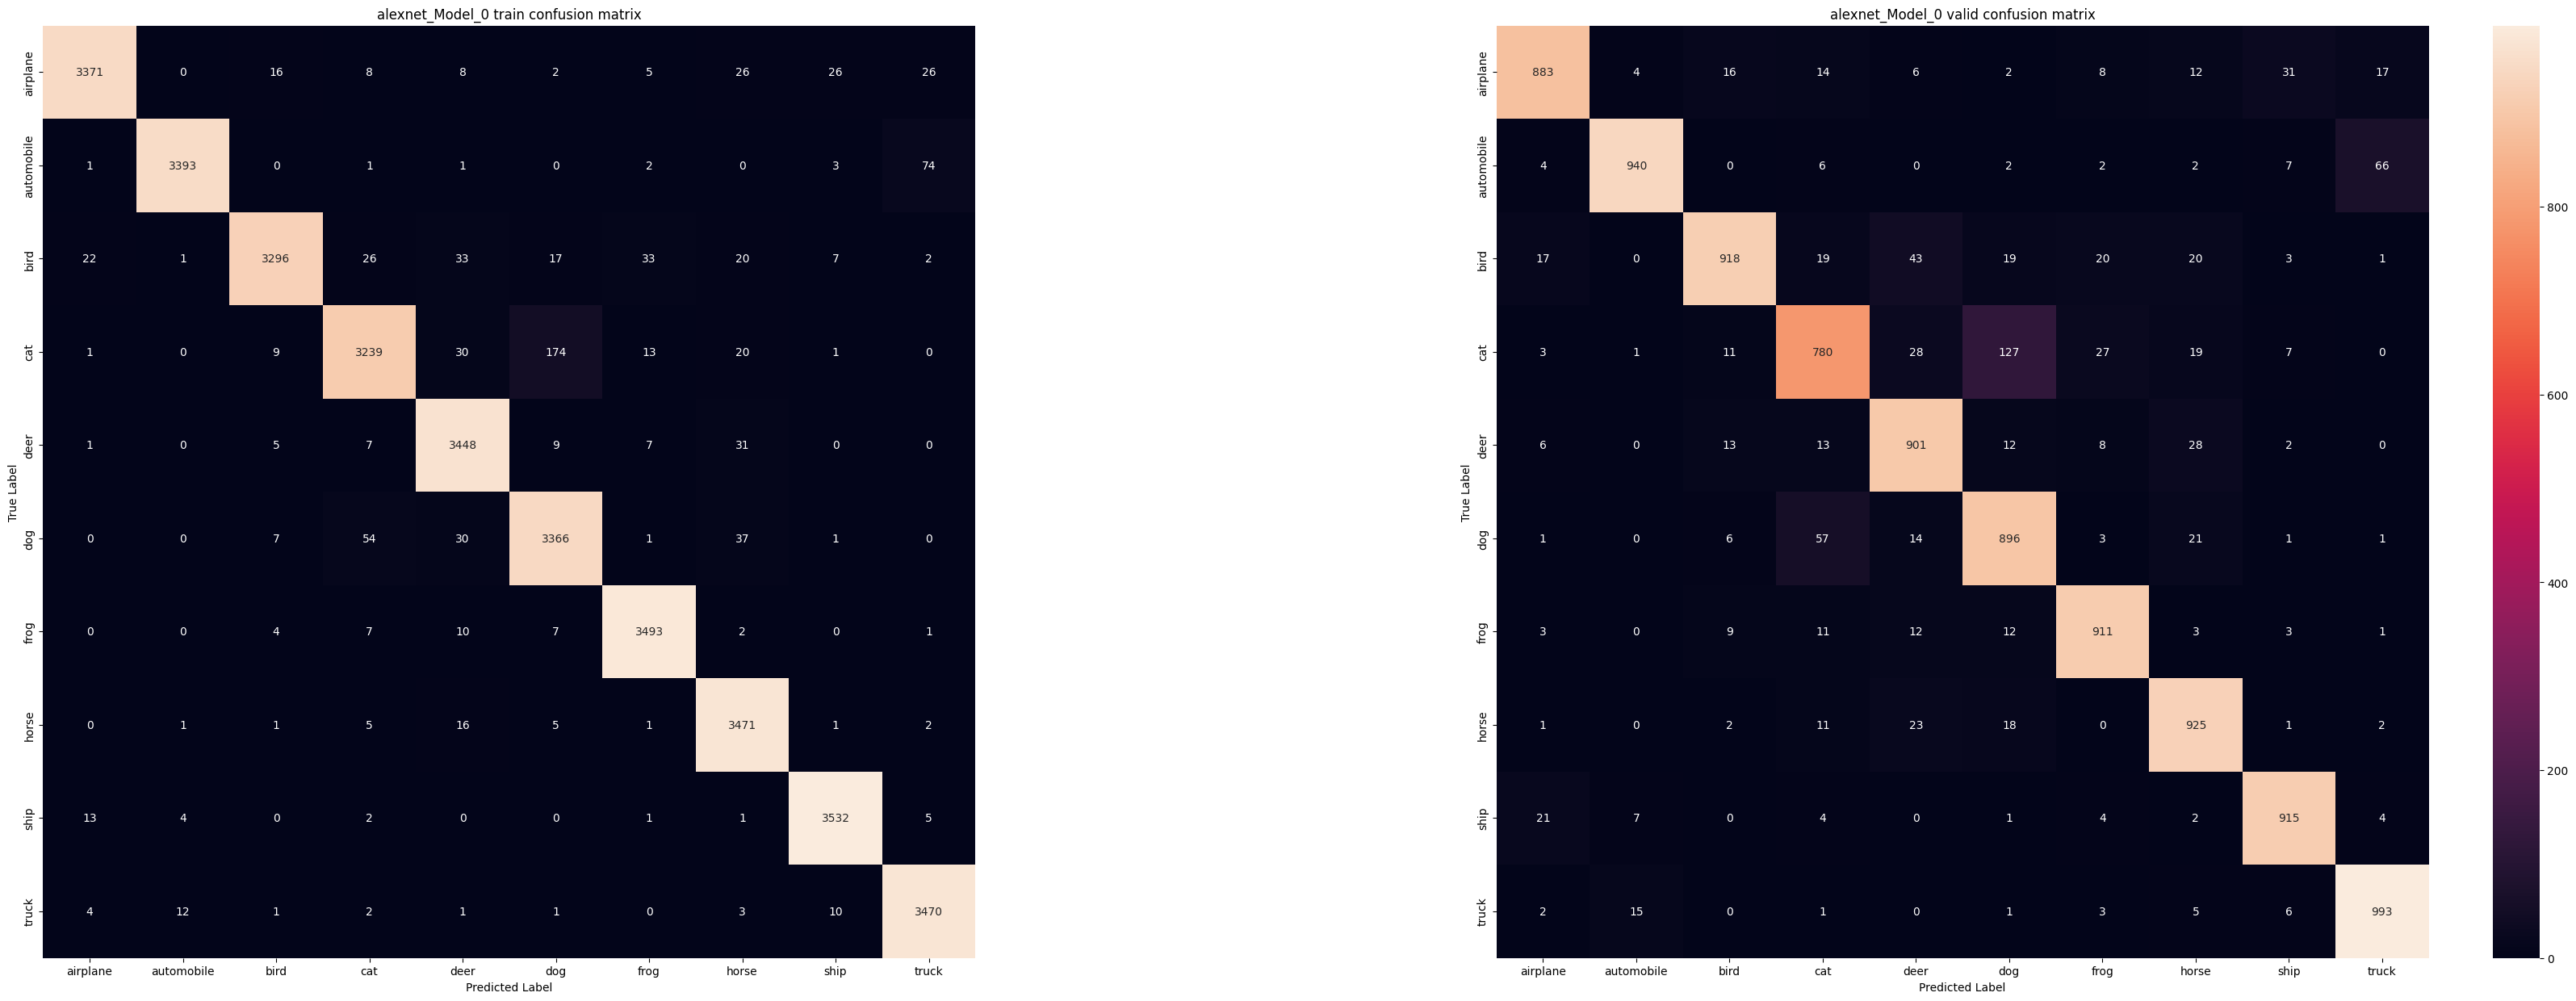

In [43]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [44]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [45]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.06534585 0.02471962 0.01340446 0.01201087 0.0111468  0.01110787
 0.01097116 0.01095106 0.01068092 0.01059882 0.01010199 0.00859568
 0.00745413 0.00716294 0.00691985]
Top 15 Positions:
[(5, 3), (9, 1), (7, 4), (7, 5), (5, 4), (8, 0), (4, 2), (2, 0), (6, 2), (4, 3), (3, 2), (9, 0), (7, 0), (7, 3), (5, 2)]


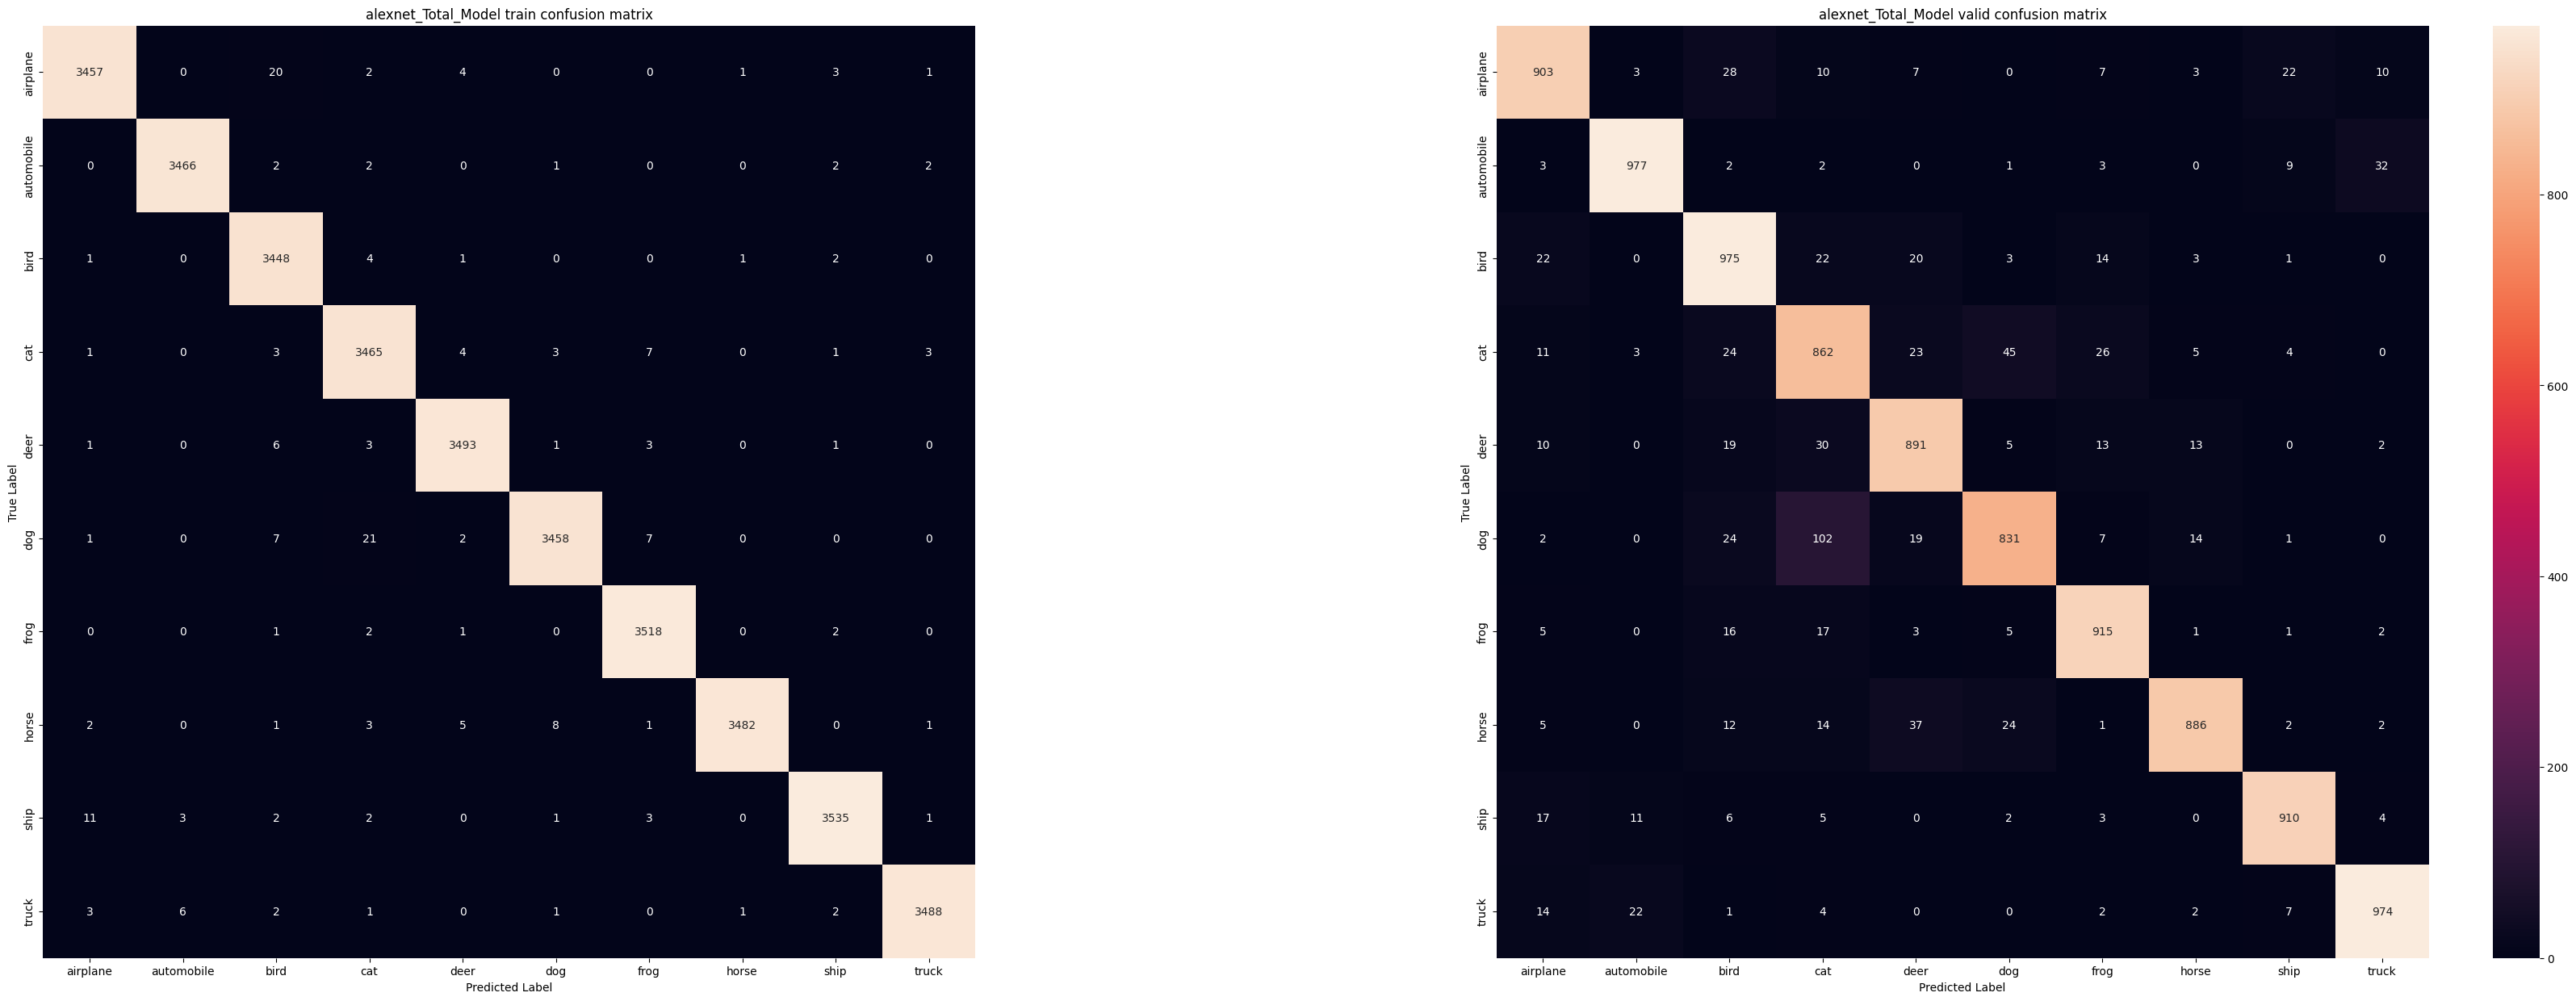

In [46]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

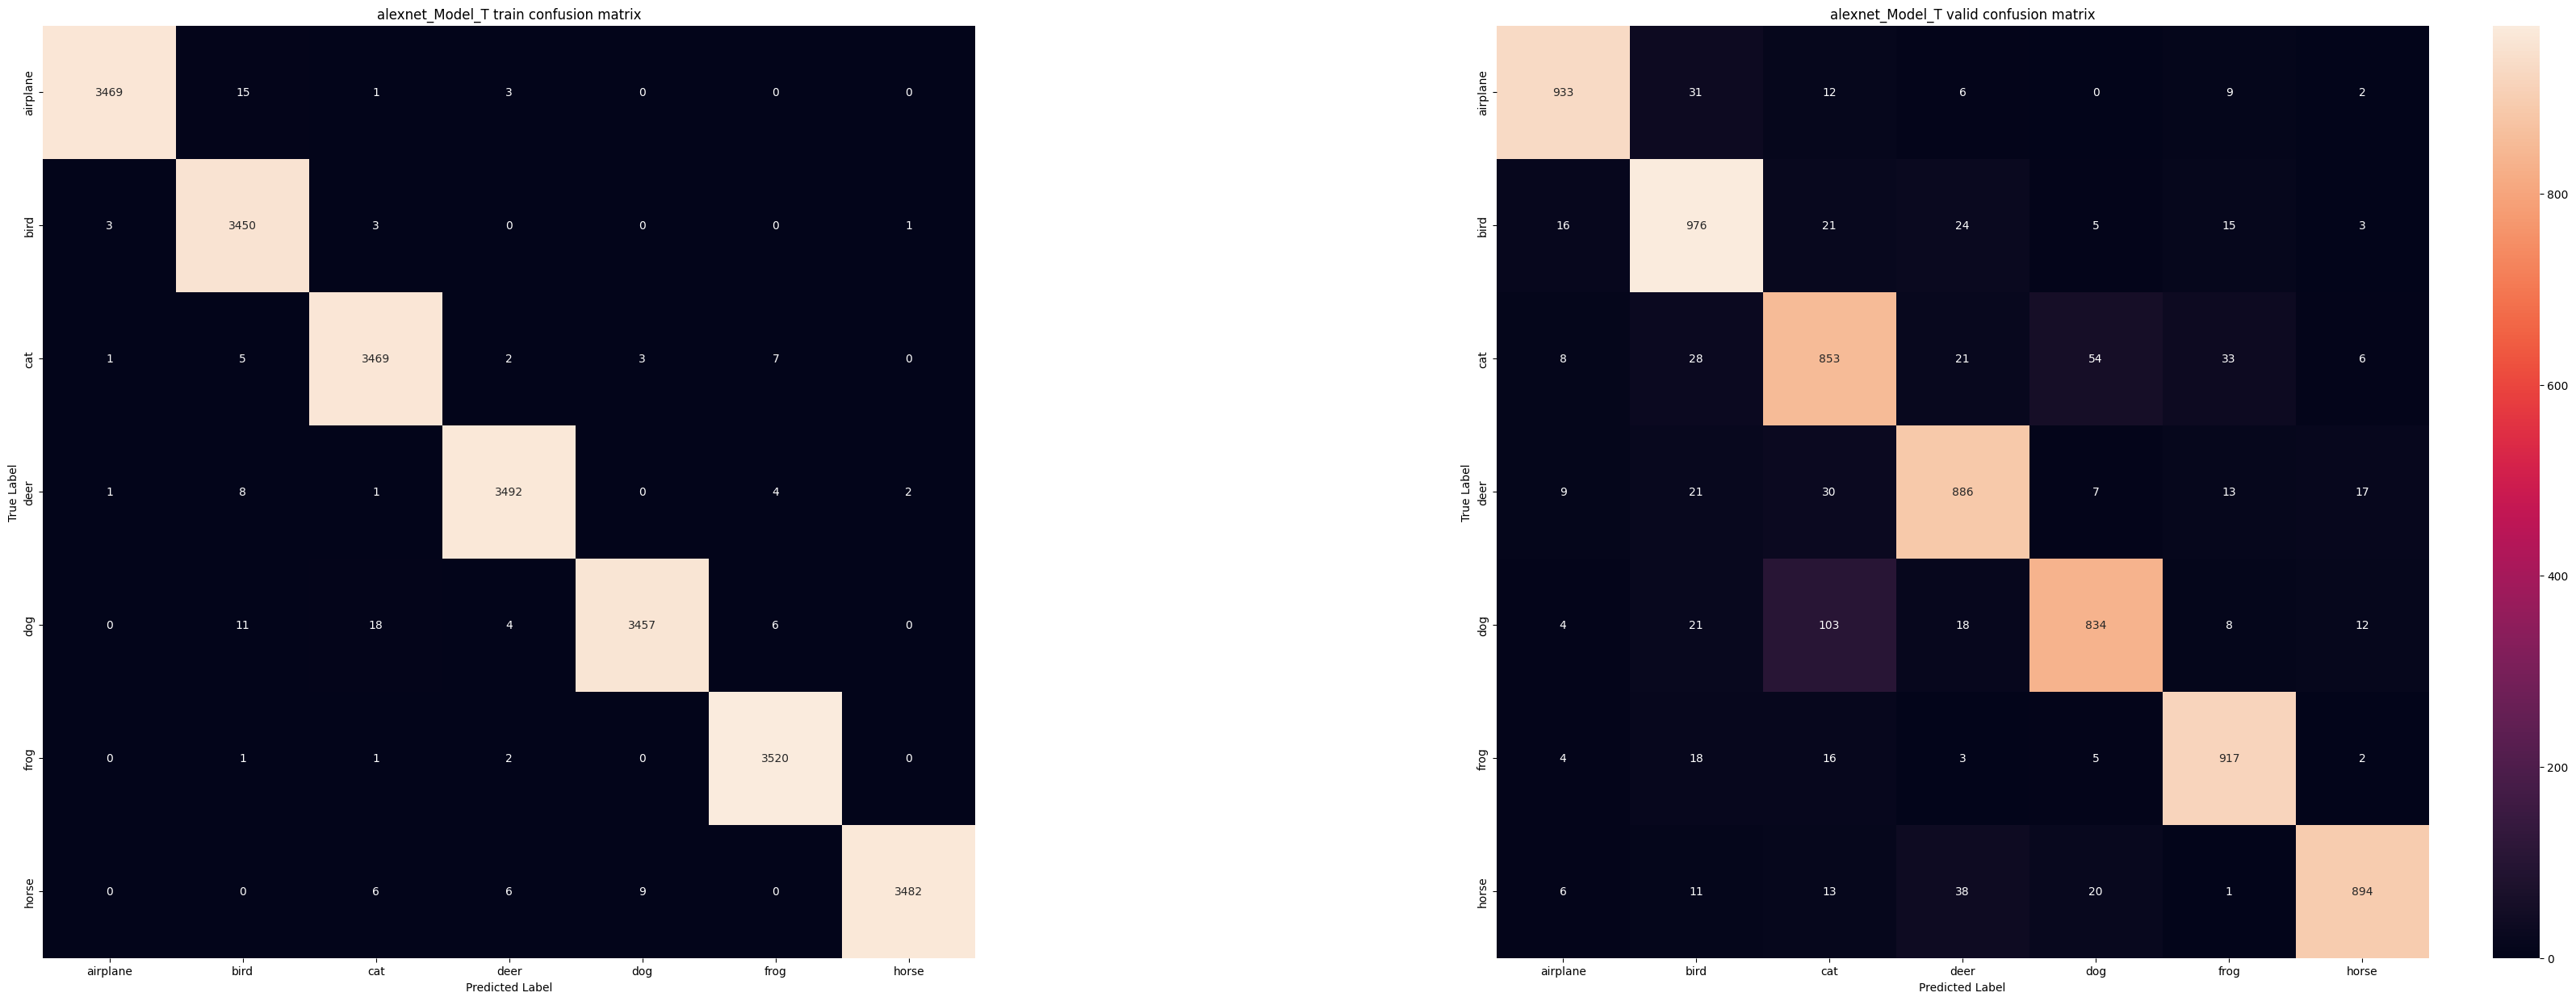

In [47]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

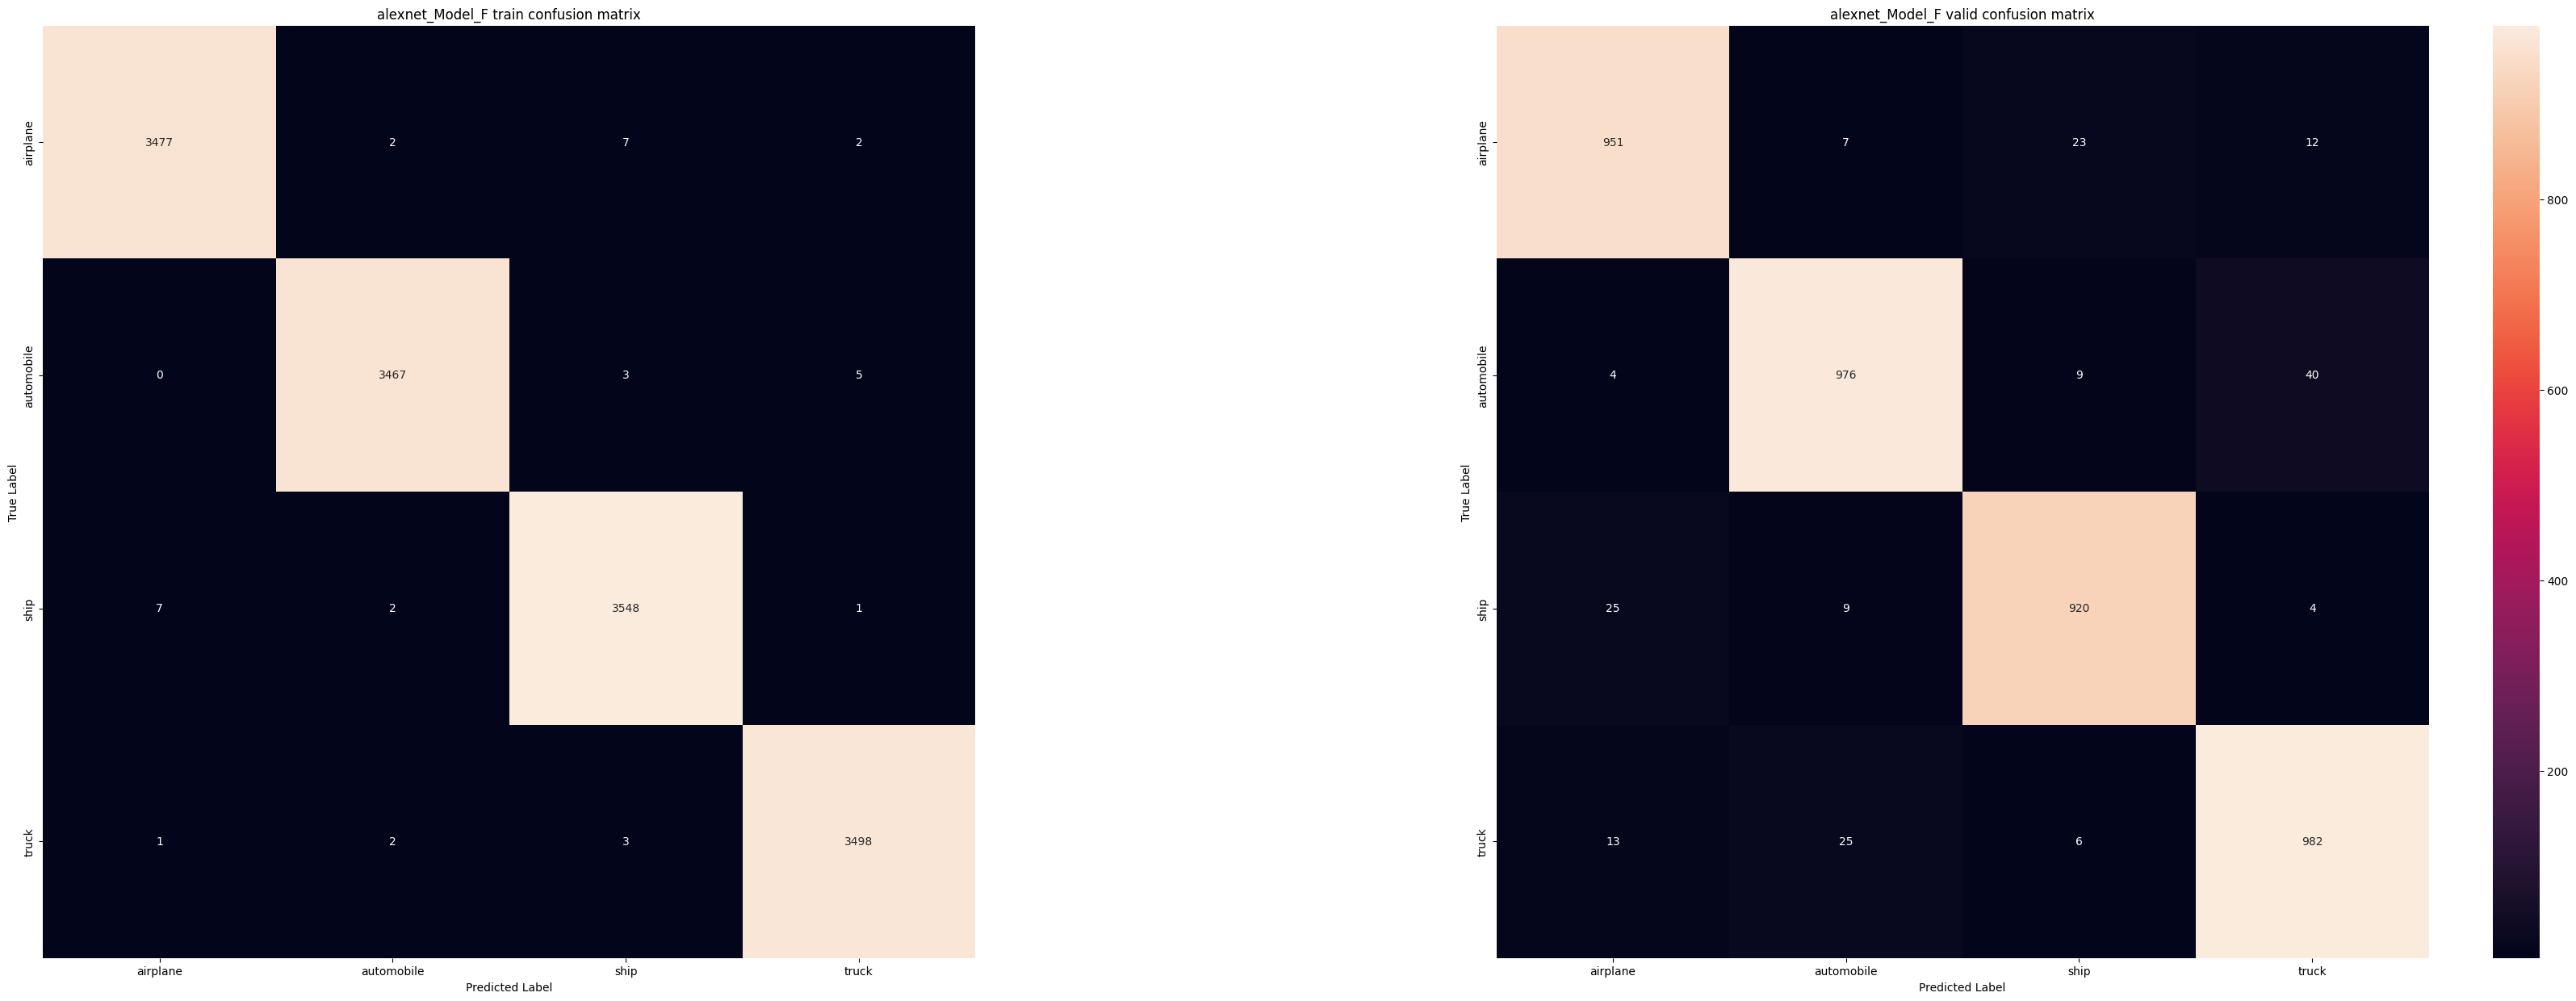

In [48]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [49]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [50]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,41448,6,1,6,6,0.915316,1.000000,0.997562,1.000000,False,True,True,True,True
1,14631,6,0,6,6,0.847135,0.997486,0.834533,0.999985,False,True,True,True,True
2,2549,5,0,5,5,0.894073,1.000000,0.999921,1.000000,False,True,True,True,True
3,27926,6,1,6,6,0.884116,1.000000,0.999903,1.000000,False,True,True,True,True
4,46705,9,9,0,9,0.999921,0.997895,0.999992,1.000000,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,20871,4,0,4,4,0.999424,0.996365,0.990174,1.000000,False,True,True,True,True
34996,30125,4,0,4,4,0.998260,0.999451,0.999653,1.000000,False,True,True,True,True
34997,18262,5,1,5,5,0.772261,0.999992,0.999700,1.000000,False,True,True,True,True
34998,24105,5,0,5,5,0.997439,0.986138,0.986928,1.000000,False,True,True,True,True


In [51]:
df_results[(df_results['Target']==0)&(df_results['Match_F']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
3693,9014,0,8,0,0,0.714678,0.999999,0.973446,0.999519,False,True,True,False,False
5687,44771,0,8,0,0,0.651913,0.999956,0.959334,0.806876,False,True,True,False,False
10137,404,0,8,0,0,0.799675,0.999995,0.658447,0.999996,False,True,True,False,False
11521,27961,0,9,0,9,0.697296,0.903696,0.956896,0.731418,False,True,False,False,False
12119,10526,0,8,0,0,0.809665,0.999963,0.564061,0.998271,False,True,True,False,False
13359,36615,0,8,0,0,0.657588,0.983623,0.694696,0.691841,False,True,True,False,False
13975,13710,0,8,0,0,0.982443,0.993018,0.743046,0.803418,False,True,True,True,False
21726,32062,0,8,0,8,0.530315,0.999969,0.587445,0.999972,False,True,False,False,False
22149,39037,0,8,0,0,0.704231,0.986694,0.955084,0.982697,False,True,True,True,False
26911,2622,0,9,0,9,0.866745,1.000000,0.754289,0.998404,False,True,False,False,False


In [52]:
df_results[(df_results['Target']==0)&(df_results['Decision']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
47,39431,0,0,0,9,0.990130,0.999954,0.930532,0.999716,True,True,False,False,False
55,45390,0,0,0,0,0.999999,0.999986,0.996863,0.980154,True,True,True,False,False
73,29232,0,0,0,0,0.999765,1.000000,0.972850,0.999999,True,True,True,False,False
93,37495,0,0,0,0,0.999973,1.000000,0.993424,0.999862,True,True,True,False,False
155,34787,0,0,0,0,1.000000,1.000000,0.961792,0.999853,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34889,44476,0,0,0,0,1.000000,1.000000,0.999971,0.713619,True,True,True,False,False
34904,938,0,8,0,0,0.883549,0.994541,0.878282,0.999824,False,True,True,False,False
34907,37999,0,0,0,0,0.999979,0.999542,0.992629,0.966319,True,True,True,False,False
34928,48788,0,0,0,0,1.000000,1.000000,0.999998,0.954066,True,True,True,False,False


In [53]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
12,26427,0,0,0,0,1.000000,0.999803,0.999582,0.999996,True,True,True,True,False
16,6518,0,0,0,0,0.999999,0.999996,0.999594,0.998681,True,True,True,True,False
67,33647,0,0,0,0,0.999990,1.000000,0.928551,0.999979,True,True,True,True,False
71,41741,0,0,0,0,0.999923,0.999990,0.998170,0.518326,True,True,True,True,False
108,11372,0,0,0,0,0.999995,0.999073,0.866442,0.801216,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34963,23462,0,0,0,0,1.000000,1.000000,0.998651,0.997726,True,True,True,True,False
34974,47381,0,0,0,0,0.999997,0.999888,0.999808,0.999872,True,True,True,True,False
34976,23077,0,0,0,0,0.999993,0.999899,0.998973,0.999886,True,True,True,True,False
34981,48266,0,0,0,0,1.000000,0.999969,0.982639,0.999561,True,True,True,True,False


In [54]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

0    2192
8      11
2       5
9       4
1       4
6       3
3       3
5       1
Name: Target, dtype: int64

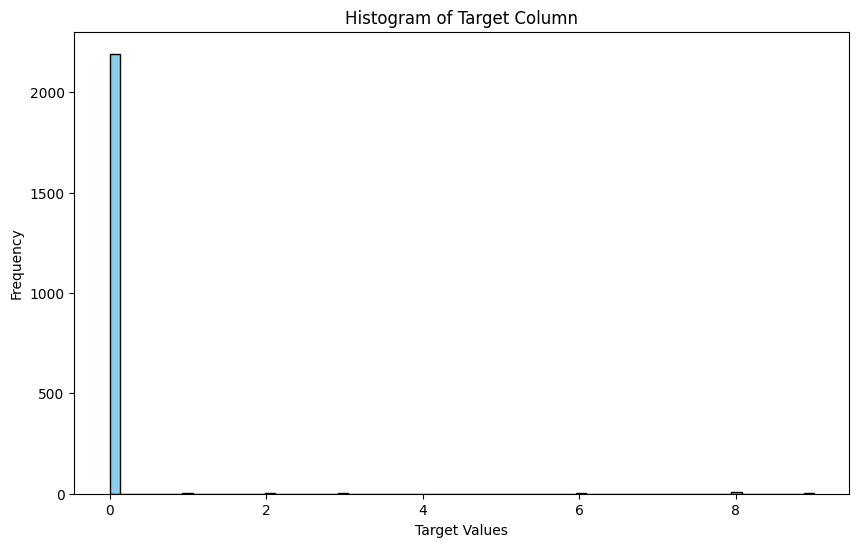

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

218

In [57]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

8

In [58]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
71,41741,0,0,0,0,0.999923,0.999990,0.998170,0.518326,True,True,True,True,False
108,11372,0,0,0,0,0.999995,0.999073,0.866442,0.801216,True,True,True,True,False
185,44956,0,0,0,0,0.999994,0.991086,0.898586,0.536706,True,True,True,True,False
208,20759,0,0,0,0,0.998750,0.975114,0.762571,0.674681,True,True,True,True,False
396,12854,0,0,0,0,0.998920,1.000000,0.952911,0.866847,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34871,37841,0,0,0,0,0.942695,0.998451,0.998432,0.641946,True,True,True,True,False
34874,24605,0,0,0,0,0.999657,0.999984,0.348831,0.819624,True,True,True,True,False
34876,49219,0,0,0,0,0.996321,0.998017,0.466138,0.599335,True,True,True,True,False
34890,5864,0,0,0,0,0.973591,0.972460,0.553617,0.877915,True,True,True,True,False


In [59]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,10522,1,1,3,1,0.966296,0.617346,0.974920,1.000000,True,False,True,False,False
1,10417,2,8,2,2,0.976900,0.879670,0.813856,1.000000,False,True,True,True,True
2,14022,4,0,4,7,0.999886,0.647192,0.592454,0.999998,False,True,False,True,True
3,16126,4,0,4,4,1.000000,1.000000,0.999997,1.000000,False,True,True,True,True
4,28518,2,9,2,2,0.539917,0.999619,0.674011,0.999999,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,16685,6,9,6,6,0.415545,0.999570,0.922897,0.999988,False,True,True,True,True
9996,29391,6,8,6,6,0.975293,1.000000,0.999998,0.999999,False,True,True,True,True
9997,1523,2,0,4,4,0.999620,0.998742,0.991231,1.000000,False,False,False,True,True
9998,5325,7,0,4,4,0.999950,0.568046,0.535024,1.000000,False,False,False,True,True


In [60]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

57

In [61]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

4

In [62]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
8,13011,0,0,0,0,0.997350,0.993705,0.495415,0.997558,True,True,True,True,False
16,38043,0,0,2,0,0.999999,0.974923,0.735074,0.999923,True,False,True,True,False
48,8296,0,0,0,0,1.000000,0.705225,0.922155,0.999880,True,True,True,True,False
57,35391,0,0,0,0,1.000000,0.999778,0.999583,0.999971,True,True,True,True,False
71,17224,0,0,0,0,0.999998,0.998439,0.991254,0.972455,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9889,42231,0,0,0,0,1.000000,1.000000,0.999981,0.940309,True,True,True,True,False
9914,14153,0,0,0,0,1.000000,1.000000,0.999977,0.999588,True,True,True,True,False
9918,31023,0,0,0,3,1.000000,0.954981,0.436413,0.999901,True,True,False,True,False
9984,44746,0,0,0,0,1.000000,0.999998,0.999965,1.000000,True,True,True,True,False


In [63]:
df_results_v[(df_results_v['Target']==0)&(df_results_v['Match_T']!=True)&(df_results_v['Decision']==True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
16,38043,0,0,2,0,0.999999,0.974923,0.735074,0.999923,True,False,True,True,False
126,7805,0,0,2,2,0.648523,0.998447,0.993372,0.998748,True,False,False,True,False
310,40271,0,0,4,0,0.999999,0.756569,0.991707,0.987920,True,False,True,True,False
421,26081,0,0,3,3,0.979409,0.765827,0.685574,0.999981,True,False,False,True,False
436,21903,0,0,4,0,0.999995,0.572208,0.875916,0.986992,True,False,True,True,False
610,12393,0,0,6,6,0.999990,0.853107,0.566355,0.999939,True,False,False,True,False
825,38628,0,0,6,4,0.999841,0.959541,0.452370,0.999988,True,False,False,True,False
851,41274,0,0,4,2,0.999161,0.857344,0.589765,0.999997,True,False,False,True,False
2225,22258,0,0,7,7,0.999997,0.740042,0.640706,0.999824,True,False,False,True,False
2439,7581,0,0,2,3,0.999980,0.954602,0.996154,1.000000,True,False,False,True,False


In [64]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

0    610
8     21
9     12
3     12
1     10
4      3
6      3
2      2
7      2
5      1
Name: Target, dtype: int64

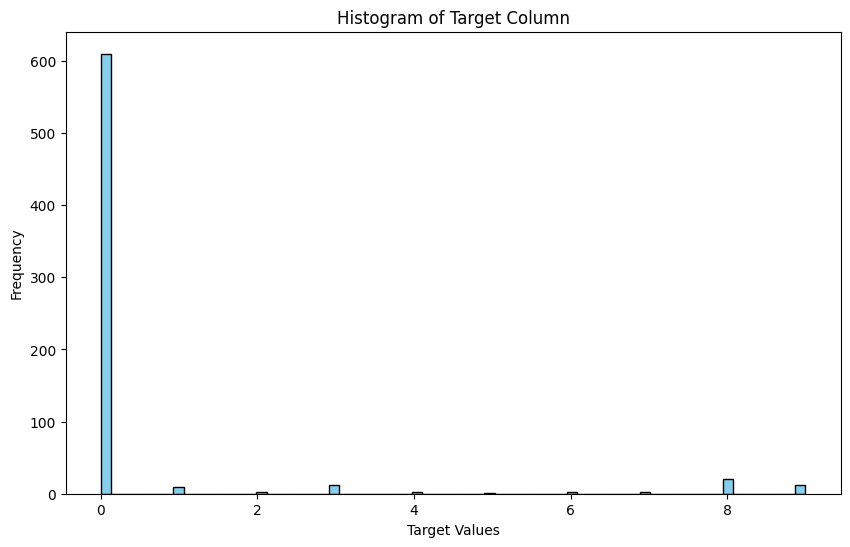

In [65]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [66]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (abs(df_results_v['Softmax_F']-df_results_v['Softmax_T'])>0.2)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
48,8296,0,0,0,0,1.000000,0.705225,0.922155,0.999880,True,True,True,True,False
126,7805,0,0,2,2,0.648523,0.998447,0.993372,0.998748,True,False,False,True,False
135,30148,8,8,3,3,0.999999,0.697552,0.831614,0.998329,True,False,False,True,False
203,10486,0,0,0,0,1.000000,0.742232,0.988425,0.999996,True,True,True,True,False
234,27041,9,0,6,6,0.674481,0.965575,0.369189,0.910018,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9377,41256,8,8,0,0,0.726456,0.996791,0.642257,0.847156,True,False,False,True,False
9601,37570,1,1,4,4,0.999959,0.522149,0.350170,0.889231,True,False,False,True,False
9606,42248,0,0,0,0,0.999990,0.500420,0.627622,0.999333,True,True,True,True,False
9617,10681,0,0,0,7,0.738978,0.334684,0.886158,0.966649,True,True,False,True,False


In [67]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
8,13011,0,0,0,0,0.997350,0.993705,0.495415,0.997558,True,True,True,True,False
16,38043,0,0,2,0,0.999999,0.974923,0.735074,0.999923,True,False,True,True,False
48,8296,0,0,0,0,1.000000,0.705225,0.922155,0.999880,True,True,True,True,False
57,35391,0,0,0,0,1.000000,0.999778,0.999583,0.999971,True,True,True,True,False
71,17224,0,0,0,0,0.999998,0.998439,0.991254,0.972455,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9889,42231,0,0,0,0,1.000000,1.000000,0.999981,0.940309,True,True,True,True,False
9914,14153,0,0,0,0,1.000000,1.000000,0.999977,0.999588,True,True,True,True,False
9918,31023,0,0,0,3,1.000000,0.954981,0.436413,0.999901,True,True,False,True,False
9984,44746,0,0,0,0,1.000000,0.999998,0.999965,1.000000,True,True,True,True,False


In [68]:
# #全部模型裝在一起的表現
# def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
#     total_loss = 0
#     accu = 0
#     flat_true=[]
#     flat_pred=[]
#     sum_F=0
#     sum_T=0
#     with torch.no_grad():
#         for data,target,idx in data_dl:
#             outputs=[]
#             data,target=data.to(device),target.to(device)
#             out_growth = model_0(data)
#             softmax_0=torch.softmax(out_growth, dim=1)

#             out_T = model_T(data)
#             softmax_T=torch.softmax(out_T, dim=1)

#             out_F = model_F(data)
#             softmax_F=torch.softmax(out_F, dim=1)

         
            
#             for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
#                 st_max=torch.max(st).item()
#                 sf_max=torch.max(sf).item()

#                 out_decision=model_decision(d.unsqueeze(0))
#                 _, pred = torch.max(out_decision, dim = 1) 
#                 softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
#                 if(softmax_decision<0.9):
#                     # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
#                     # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
#                     if(sf_max>st_max):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1
#                 else:
                   
#                     if(pred==0):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1

#             outputs = torch.cat(outputs, dim=0)
#             _, y_pred_tag = torch.max(outputs, dim = 1)
#             loss = criterion(outputs, target)


#             flat_true.extend(target.cpu().numpy())
#             flat_pred.extend(y_pred_tag.cpu().numpy())

#             total_loss+= loss.item()*data.size(0)
#             correct=torch.sum(y_pred_tag == target).item()
#             accu += correct      

#     total_loss=total_loss/size
#     accu=accu/size
#     idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
#     confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
#     return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [69]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [70]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.12893441089812133, 0.9914571428571428, 11952, 23048)

In [71]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.9570294417552649, 0.9011, 3611, 6389)

In [72]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score
#模型表現
def evaluate_metric_model(model,data_dl,size,data_name,mode=None):
        
        model.to(device)
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   
            for data, target,idx in data_dl:
                    
                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)

                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        # 计算各种指标
        precision = precision_score(flat_true, flat_pred, average='macro')
        recall = recall_score(flat_true, flat_pred, average='macro')
        f1 = f1_score(flat_true, flat_pred, average='macro')
        

        a=sorted(set(flat_true))
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu,precision,recall,f1

In [73]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.08387465683136668,
 0.9740857142857143,
 0.9742840671765451,
 0.9739965956061493,
 0.9740090001287554)

In [74]:
evaluate_metric_model(model_0,valid_dl,valid_size,"0",mode=None)

(0.29049503950476646,
 0.907,
 0.9077895102947305,
 0.9075751131839862,
 0.9067642207735892)

In [75]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)